In [9]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import hdbscan
import optuna
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

from Src.data import load_csv_df
from Src.plotting import set_plotting_style, draw_model_clusters
from Src.model import save_model_result, print_model_result, create_cluster_objective

In [10]:
# Already prepared accent palette applying using function from mine Src module (plotting)
set_plotting_style()

In [11]:
DF_PATH = "../Data/Processed/processed-data.csv"

# Safely loading dataframe using function from mine Src module (data)
df = load_csv_df(
    df_path=DF_PATH,
)

Successfully loaded dataframe: ..\Data\Processed\processed-data.csv
Dataframe has: 8950 rows / 6 columns
Dataframe size: 0.410MB


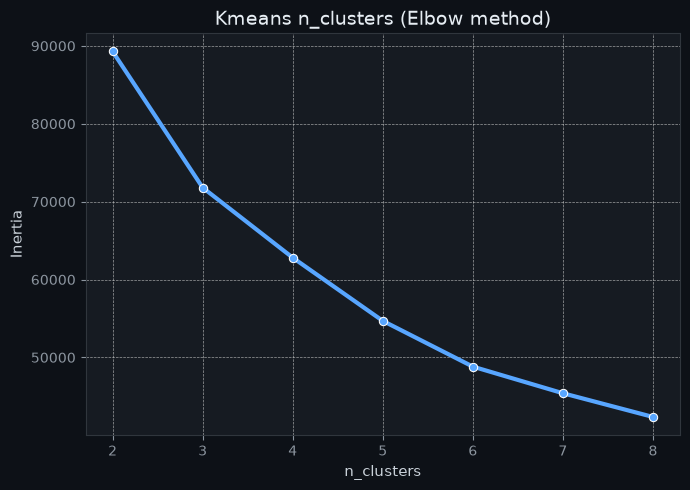

In [12]:
"""I will compare 3 models (KMeans, DBSCAN, HDBSCAN)

First one is KMeans
Second one is DBSCAN
Final is HDBSCAN

All models will be rated by silhouette, davies and calinski metrics
"""
inertia_list = []
n_clusters = range(2, 9)

for n in n_clusters:
    model = KMeans(
        n_clusters=n,
        random_state=42,
        n_init=10
    )
    model.fit(df)
    inertia_list.append(model.inertia_)

plt.figure(figsize=(7, 5))
sns.lineplot(
    x=list(n_clusters),
    y=inertia_list,
    marker="o",
    linewidth=3,
)

plt.title("Kmeans n_clusters (Elbow method)")
plt.xlabel("n_clusters")
plt.ylabel("Inertia")
plt.tight_layout()
plt.show()

# The best n_clusters is 5
BEST_N_CLUSTERS = 5


                    Clustering Results
model_name  silhouette_score  davies_score  calinski_score
    KMeans             0.271         1.334        3000.519



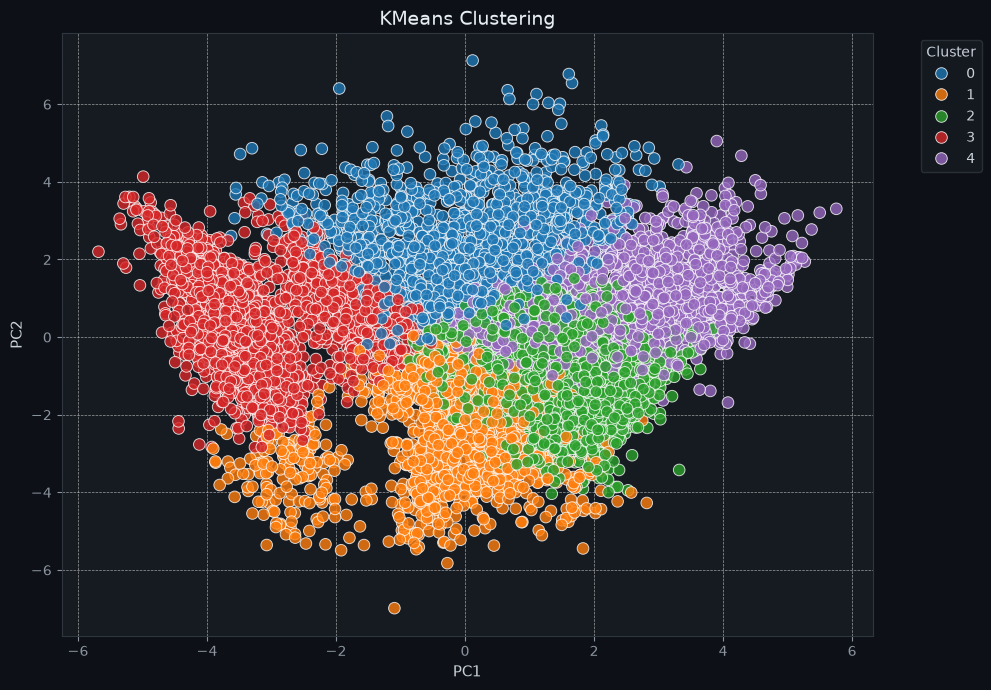

In [13]:
"""
List where will be all 3 model results
There will be model_name, silhouette_score, calinski_harabasz_score, davies_bouldin_score
"""
MODEL_RESULTS = []

kmeans_model = KMeans(
    n_clusters=BEST_N_CLUSTERS,
    random_state=42,
    n_init="auto"
)

# Saving model results using func from mine Src module (model)
MODEL_RESULTS = save_model_result(
    results=MODEL_RESULTS,
    model_name="KMeans",
    x=df,
    model=kmeans_model
)
# Printing all model results using func from mine Src module (model)
print_model_result(MODEL_RESULTS)

# Drawing KMeans clustering using func from mine Src module (plotting)
draw_model_clusters(
    model=kmeans_model,
    title="KMeans Clustering",
    x=df
)

In [14]:
# The next model is DBSCAN
optuna.logging.set_verbosity(optuna.logging.WARNING)

# Creating objective trial for dbscan (optuna) using func from mine Src module (model)
dbscan_objective = create_cluster_objective(
    x=df,
    algorithm="dbscan",
    max_noise_ratio=0.3
)

study_dbscan = optuna.create_study(direction="maximize")
study_dbscan.optimize(dbscan_objective, n_trials=50)

print("\n" + "=" * 50)
print(" " * 12 + "DBSCAN Optuna Best Results")
print("=" * 50)
print(f"Best Silhouette Score: {study_dbscan.best_value:.3f}")
print("Best Parameters:")

for param_name, param_value in study_dbscan.best_params.items():
    print(f"  - {param_name}: {param_value}")
print("=" * 50 + "\n")

# The best EPS parameter is 1.05 but the best min_samples is 19
BEST_EPS = 1.05
BEST_MIN_SAMPLES = 19


            DBSCAN Optuna Best Results
Best Silhouette Score: 0.238
Best Parameters:
  - eps: 1.0
  - min_samples: 8



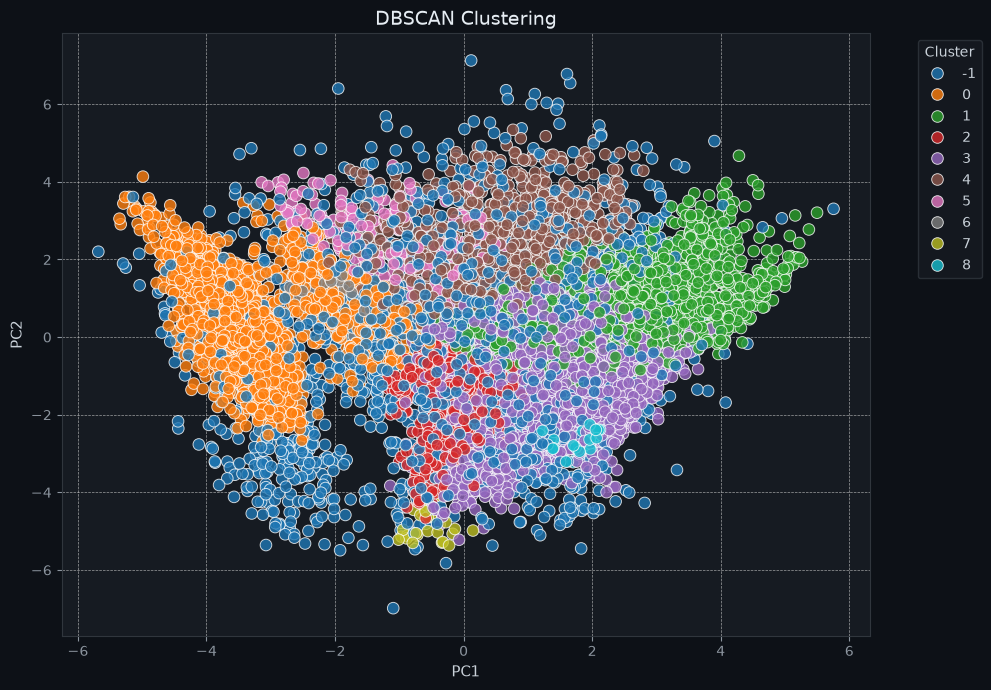

In [16]:
dbscan_model = DBSCAN(
    eps=BEST_EPS,
    min_samples=BEST_MIN_SAMPLES
)

MODEL_RESULTS = save_model_result(
    results=MODEL_RESULTS,
    model_name="DBSCAN",
    x=df,
    model=dbscan_model
)

# Drawing DBSCAN clustering using func from mine Src module (plotting)
draw_model_clusters(
    model=dbscan_model,
    title="DBSCAN Clustering",
    x=df
)